# 第25篇｜多子图布局与组合图表：制作一页多图分析仪表盘

> 这是「数据分析从入门到精通」系列的第 25 篇。单张图表的套路都会了，这篇来挑战更高难度——多子图布局和组合图表。一页排多张图，制作分析仪表盘，汇报时直接秀出来，让人眼前一亮。

---

嗨，我是小荷～

学到这里，你已经会画各种单图了。但真实的分析报告，往往需要把多张图放到一张大画布上，形成一个**分析仪表盘**——让人一眼就能看到整体结论。

今天我们来学 Matplotlib 的多子图布局和 Seaborn 的 FacetGrid，以及如何把不同类型的图组合成一个有层次的完整页面。

萧何当年给刘邦呈报工作，不会把每件事单独写成一张竹简——他会整理成一份结构清晰的报告。图表也是这个道理。

---

## 一、subplots 基础布局

### 均匀分割

来看看均匀分割怎么实现：


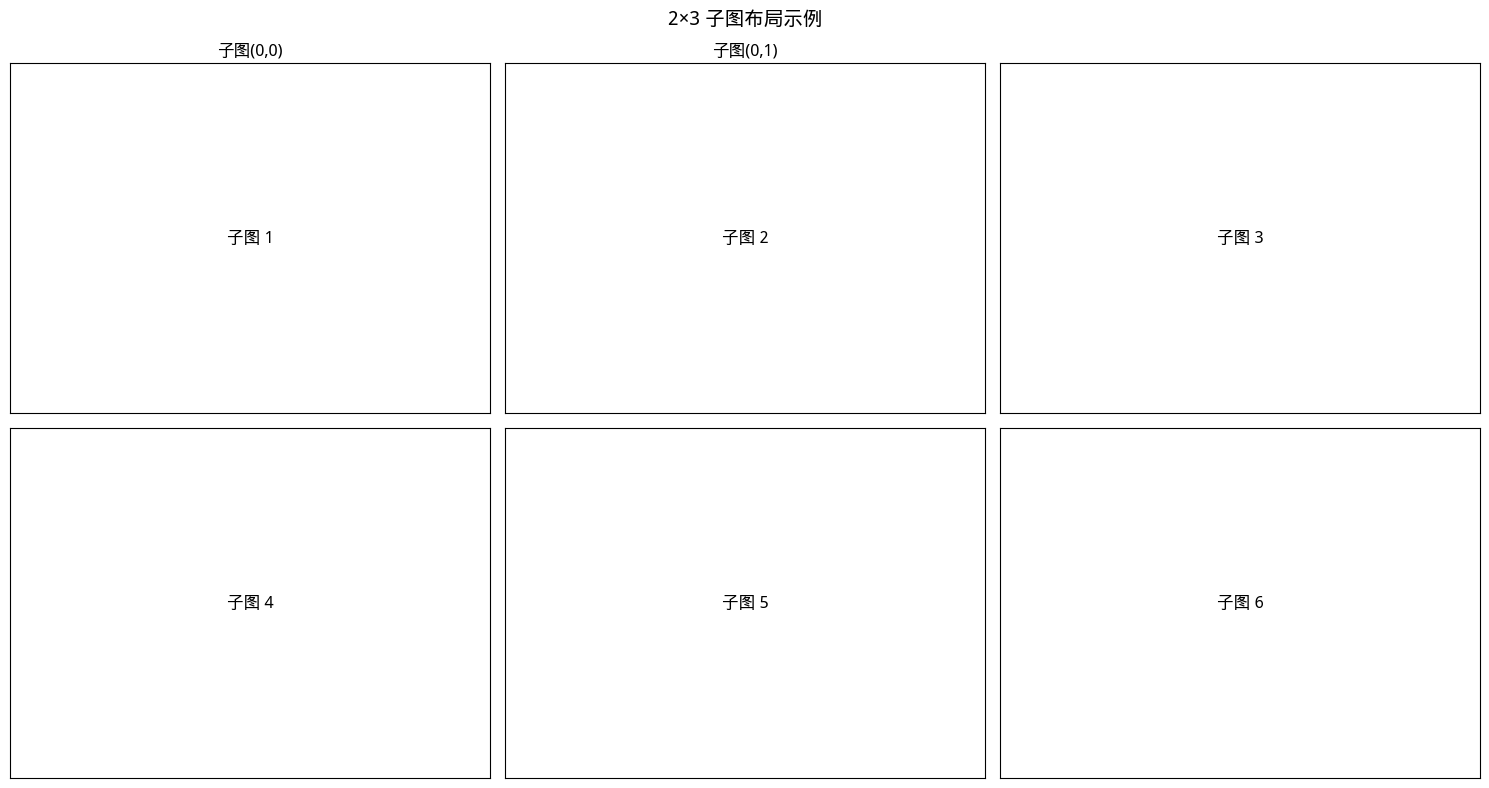

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False

# 2行3列，共6个子图
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# axes 是一个 2×3 的数组，用 axes[行][列] 访问
axes[0, 0].set_title('子图(0,0)')
axes[0, 1].set_title('子图(0,1)')
# ...

# 用 axes.flat 遍历所有子图
for i, ax in enumerate(axes.flat):
    ax.text(0.5, 0.5, f'子图 {i+1}', ha='center', va='center', fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('2×3 子图布局示例', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 共享坐标轴

来看看共享坐标轴怎么实现：


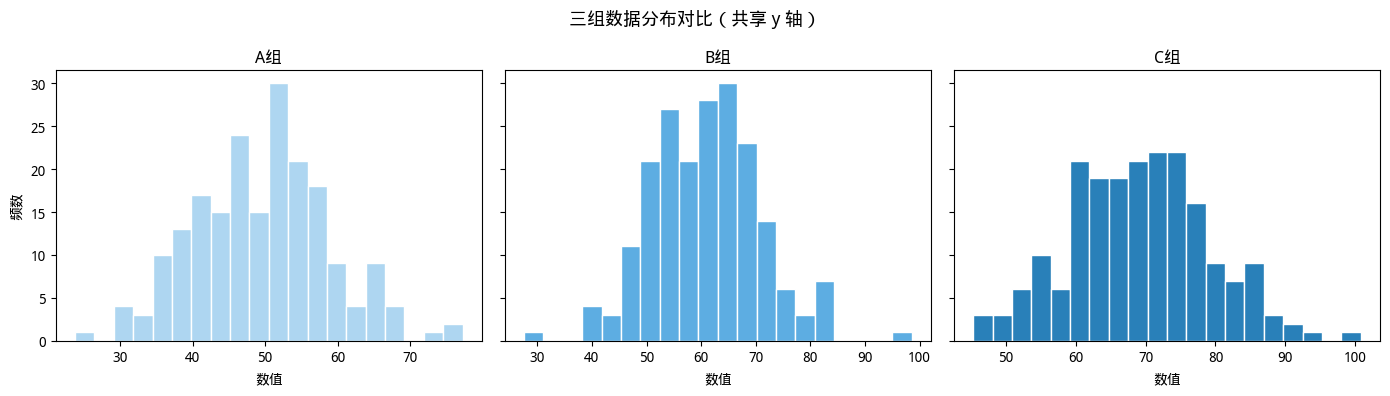

In [2]:
# 同一行的图共享 y 轴（方便对比）
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

np.random.seed(42)
groups = ['A组', 'B组', 'C组']
for i, (ax, group) in enumerate(zip(axes, groups)):
    data = np.random.normal(50 + i*10, 10, 200)
    ax.hist(data, bins=20, color=['#AED6F1', '#5DADE2', '#2980B9'][i], edgecolor='white')
    ax.set_title(group, fontweight='bold')
    ax.set_xlabel('数值')
    if i == 0:
        ax.set_ylabel('频数')

plt.suptitle('三组数据分布对比（共享 y 轴）', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---

## 二、GridSpec：不均匀布局

`GridSpec` 允许子图占据不同大小的格子，适合"主图 + 辅图"的结构：


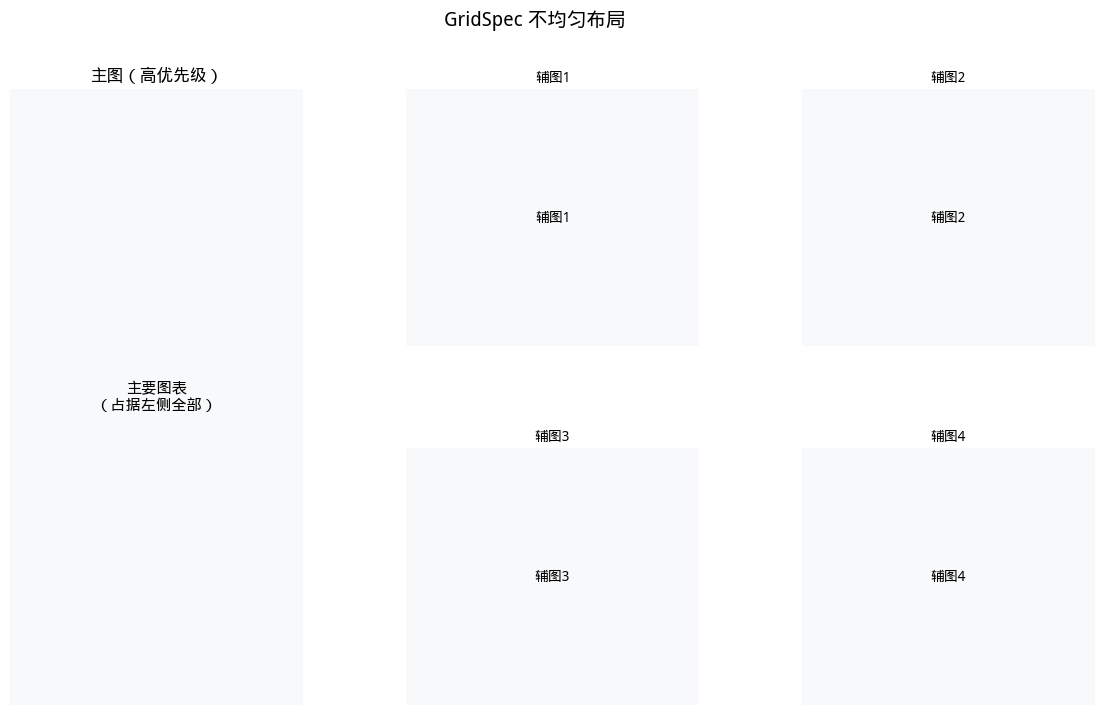

In [3]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 左侧大图：跨2行1列
ax_main = fig.add_subplot(gs[:, 0])   # 所有行，第0列

# 右侧4个小图：各占1个格子
ax_top1  = fig.add_subplot(gs[0, 1])
ax_top2  = fig.add_subplot(gs[0, 2])
ax_bot1  = fig.add_subplot(gs[1, 1])
ax_bot2  = fig.add_subplot(gs[1, 2])

# 填充示例内容
ax_main.set_title('主图（高优先级）', fontsize=12, fontweight='bold')
ax_main.text(0.5, 0.5, '主要图表\n（占据左侧全部）', ha='center', va='center', fontsize=11)

for ax, title in [(ax_top1,'辅图1'),(ax_top2,'辅图2'),(ax_bot1,'辅图3'),(ax_bot2,'辅图4')]:
    ax.set_title(title, fontsize=10)
    ax.text(0.5, 0.5, title, ha='center', va='center')

for ax in [ax_main, ax_top1, ax_top2, ax_bot1, ax_bot2]:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[:].set_visible(False)
    ax.set_facecolor('#F8F9FA')

plt.suptitle('GridSpec 不均匀布局', fontsize=14, fontweight='bold')
plt.show()


---

## 三、Seaborn FacetGrid：按分类自动分图

`FacetGrid` 可以按某列的值**自动**创建多个子图，非常适合"按城市/品类分别展示"：


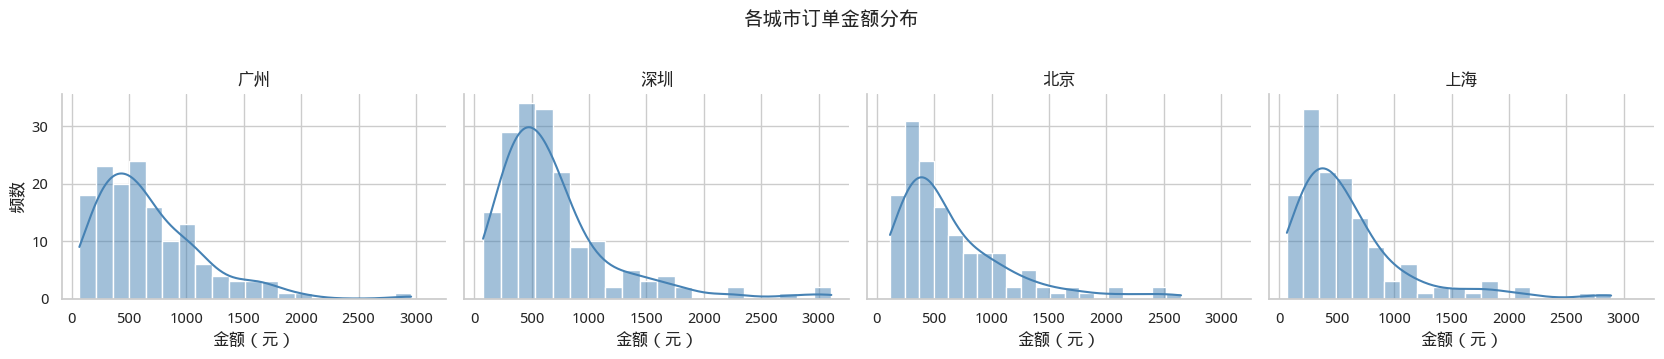

In [11]:
np.random.seed(42)
n = 600
df = pd.DataFrame({
    '城市':   np.random.choice(['北京', '上海', '广州', '深圳'], n),
    '品类':   np.random.choice(['数码', '服装', '食品'], n),
    '金额':   np.random.lognormal(6.2, 0.7, n),
    '会员':   np.random.choice(['普通', '银卡', '金卡'], n)
})

# 按城市分列，各自画 KDE 分布
g = sns.FacetGrid(df, col='城市', col_wrap=4, height=3.5, aspect=1.2)
g.map_dataframe(sns.histplot, x='金额', bins=20, kde=True, color='steelblue')
g.set_titles('{col_name}', fontweight='bold')
g.set_axis_labels('金额（元）', '频数')
g.figure.suptitle('各城市订单金额分布', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


FacetGrid 还可以同时按行和列分组，实现更精细的对比：


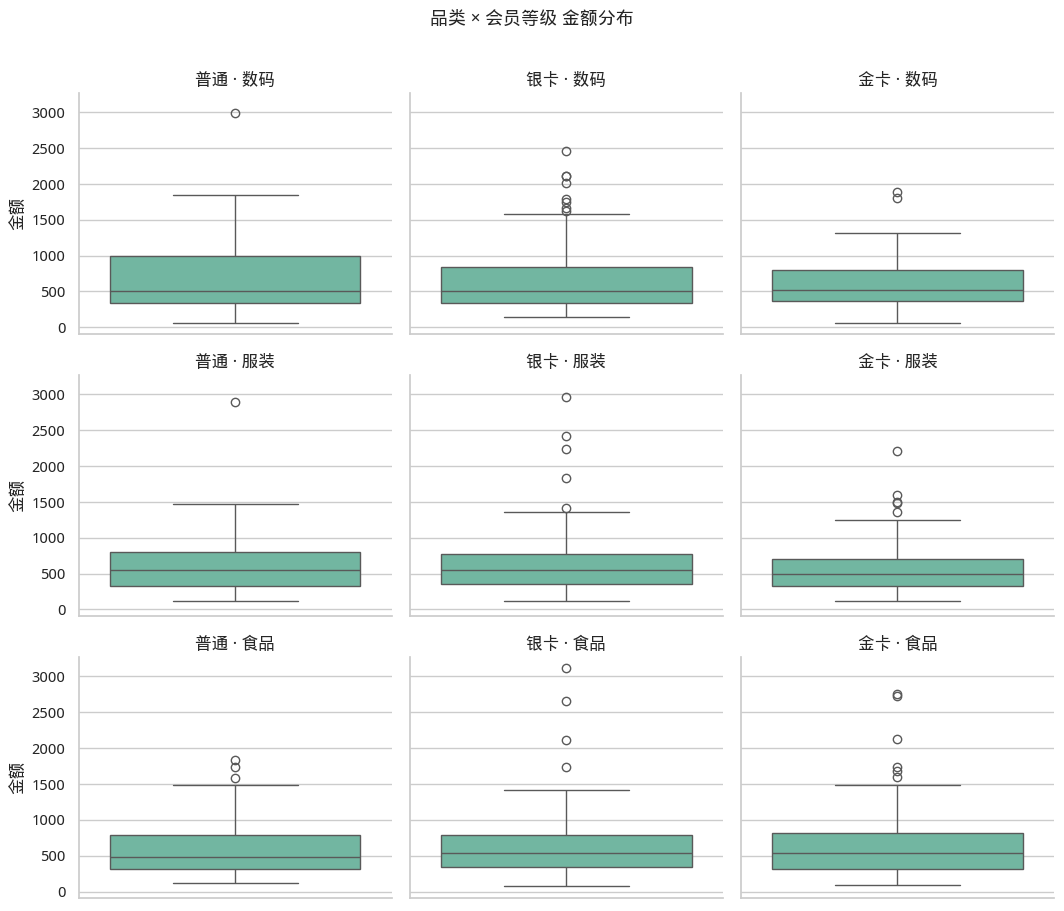

In [15]:
# 行按品类，列按会员等级
g2 = sns.FacetGrid(df, row='品类', col='会员', height=3, aspect=1.2)
g2.map_dataframe(sns.boxplot, y='金额', hue='品类',palette='Set2')
g2.set_titles('{col_name} · {row_name}')
g2.figure.suptitle('品类 × 会员等级 金额分布', fontsize=13, fontweight='bold', y=1.01)
plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.tight_layout()
plt.show()


---

## 四、🔧 综合实战：完整分析仪表盘

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：


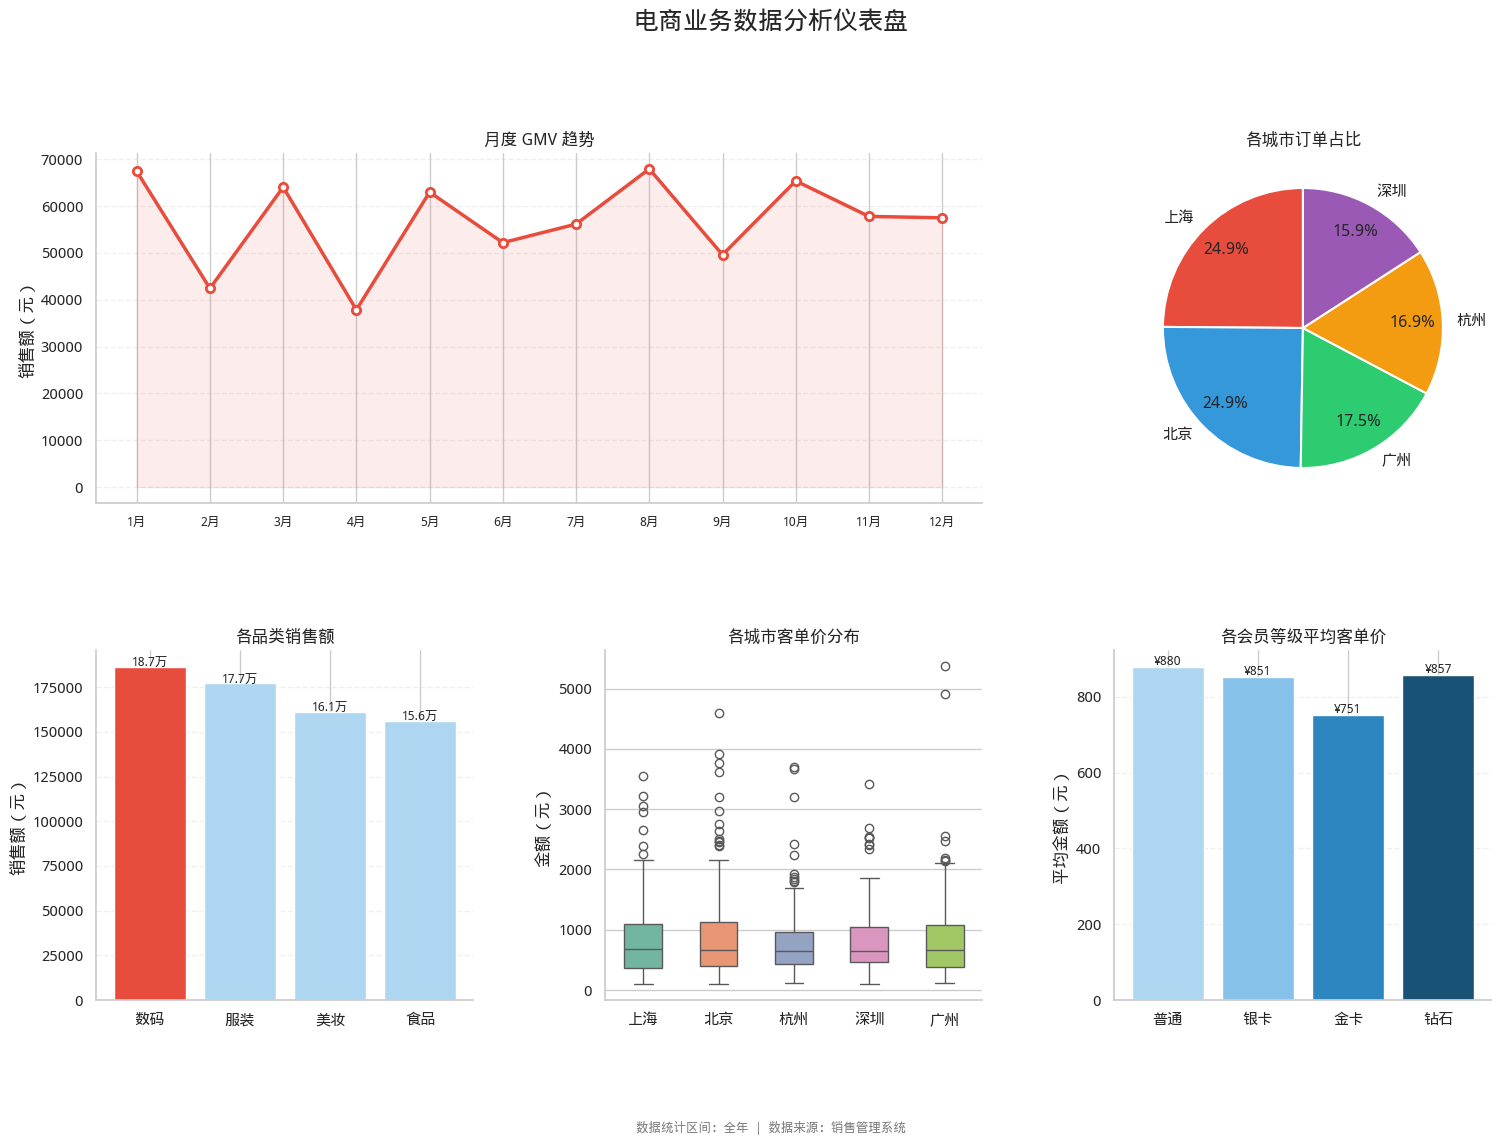

仪表盘已保存为 dashboard.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd

plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

np.random.seed(2024)
n = 800
months = ['1月','2月','3月','4月','5月','6月','7月','8月','9月','10月','11月','12月']

df = pd.DataFrame({
    'month':    np.random.choice(months, n),
    'city':     np.random.choice(['北京','上海','广州','深圳','杭州'], n, p=[0.25,0.25,0.2,0.15,0.15]),
    'category': np.random.choice(['数码','服装','食品','美妆'], n),
    'amount':   np.random.lognormal(6.5, 0.7, n),
    'level':    np.random.choice(['普通','银卡','金卡','钻石'], n, p=[0.45,0.3,0.15,0.1])
})

# 月度 GMV
monthly_gmv = df.groupby('month')['amount'].sum()
month_order = ['1月','2月','3月','4月','5月','6月','7月','8月','9月','10月','11月','12月']
monthly_gmv = monthly_gmv.reindex([m for m in month_order if m in monthly_gmv.index])

# 品类销售额
cat_sales = df.groupby('category')['amount'].sum().sort_values(ascending=False)

# 城市分布
city_orders = df['city'].value_counts()

# 会员等级
level_sales = df.groupby('level')['amount'].mean()

# ── 绘图 ──
fig = plt.figure(figsize=(18, 11))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# ── 图1（跨两列）：月度 GMV 折线 ──
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(monthly_gmv.index, monthly_gmv.values, marker='o', linewidth=2.5,
          color='#E74C3C', markersize=6, markerfacecolor='white', markeredgewidth=2)
ax1.fill_between(range(len(monthly_gmv)), monthly_gmv.values, alpha=0.1, color='#E74C3C')
ax1.set_xticks(range(len(monthly_gmv)))
ax1.set_xticklabels(monthly_gmv.index, fontsize=9)
ax1.set_title('月度 GMV 趋势', fontsize=12, fontweight='bold')
ax1.set_ylabel('销售额（元）')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── 图2：城市饼图 ──
ax2 = fig.add_subplot(gs[0, 2])
colors_pie = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
ax2.pie(city_orders.values, labels=city_orders.index,
         autopct='%1.1f%%', colors=colors_pie,
         wedgeprops=dict(edgecolor='white', linewidth=1.5),
         startangle=90, pctdistance=0.78)
ax2.set_title('各城市订单占比', fontsize=12, fontweight='bold')

# ── 图3：品类柱状图 ──
ax3 = fig.add_subplot(gs[1, 0])
colors_bar = ['#E74C3C' if i == 0 else '#AED6F1' for i in range(len(cat_sales))]
ax3.bar(cat_sales.index, cat_sales.values, color=colors_bar, edgecolor='white')
for i, (label, val) in enumerate(cat_sales.items()):
    ax3.text(i, val + 500, f'{val/10000:.1f}万', ha='center', fontsize=9)
ax3.set_title('各品类销售额', fontsize=12, fontweight='bold')
ax3.set_ylabel('销售额（元）')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# ── 图4：金额分布箱线图 ──
ax4 = fig.add_subplot(gs[1, 1])
sns.boxplot(data=df, x='city', hue='city',y='amount', palette='Set2', width=0.5, ax=ax4)
ax4.set_title('各城市客单价分布', fontsize=12, fontweight='bold')
ax4.set_xlabel('')
ax4.set_ylabel('金额（元）')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# ── 图5：会员等级均值 ──
ax5 = fig.add_subplot(gs[1, 2])
level_order = ['普通', '银卡', '金卡', '钻石']
level_vals  = [level_sales.get(l, 0) for l in level_order]
level_colors = ['#AED6F1', '#85C1E9', '#2E86C1', '#1A5276']
ax5.bar(level_order, level_vals, color=level_colors, edgecolor='white')
for i, val in enumerate(level_vals):
    ax5.text(i, val + 5, f'¥{val:.0f}', ha='center', fontsize=9)
ax5.set_title('各会员等级平均客单价', fontsize=12, fontweight='bold')
ax5.set_ylabel('平均金额（元）')
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.grid(axis='y', alpha=0.3, linestyle='--')

# ── 大标题 ──
fig.suptitle('电商业务数据分析仪表盘', fontsize=18, fontweight='bold', y=1.01)
fig.text(0.5, -0.01, '数据统计区间：全年  |  数据来源：销售管理系统',
          ha='center', fontsize=9, color='gray')
plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("仪表盘已保存为 dashboard.png")


---

## 五、📋 布局方式速查

| 方法 | 适合场景 |
|------|---------|
| `subplots(m, n)` | 均匀分割，简单多图 |
| `subplots(sharey=True)` | 多图共享轴，方便对比 |
| `GridSpec` | 不均匀分割，主图+辅图结构 |
| `FacetGrid` | 按分类自动分图，批量展示 |

---

## 六、📝 小结

好的仪表盘需要考虑：

1. **信息层级**：最重要的信息放在左上角，最大的图
2. **颜色一致**：同一类信息用同一颜色系
3. **标题清晰**：每张子图都要有标题，整体还要有大标题
4. **数值标注**：关键数字直接标在图上，不让读者费眼睛

---

## 七、🏋️ 课后练习

1. 用 `GridSpec` 做一个"主图（折线）+ 3个小图（柱/饼/箱）"的 2×2 不均匀布局。
2. 用 `FacetGrid` 按城市分列，分别画各品类的平均销售额柱状图。
3. 把你的第18篇实战数据做成一个完整仪表盘（至少4张子图），保存为 PNG。

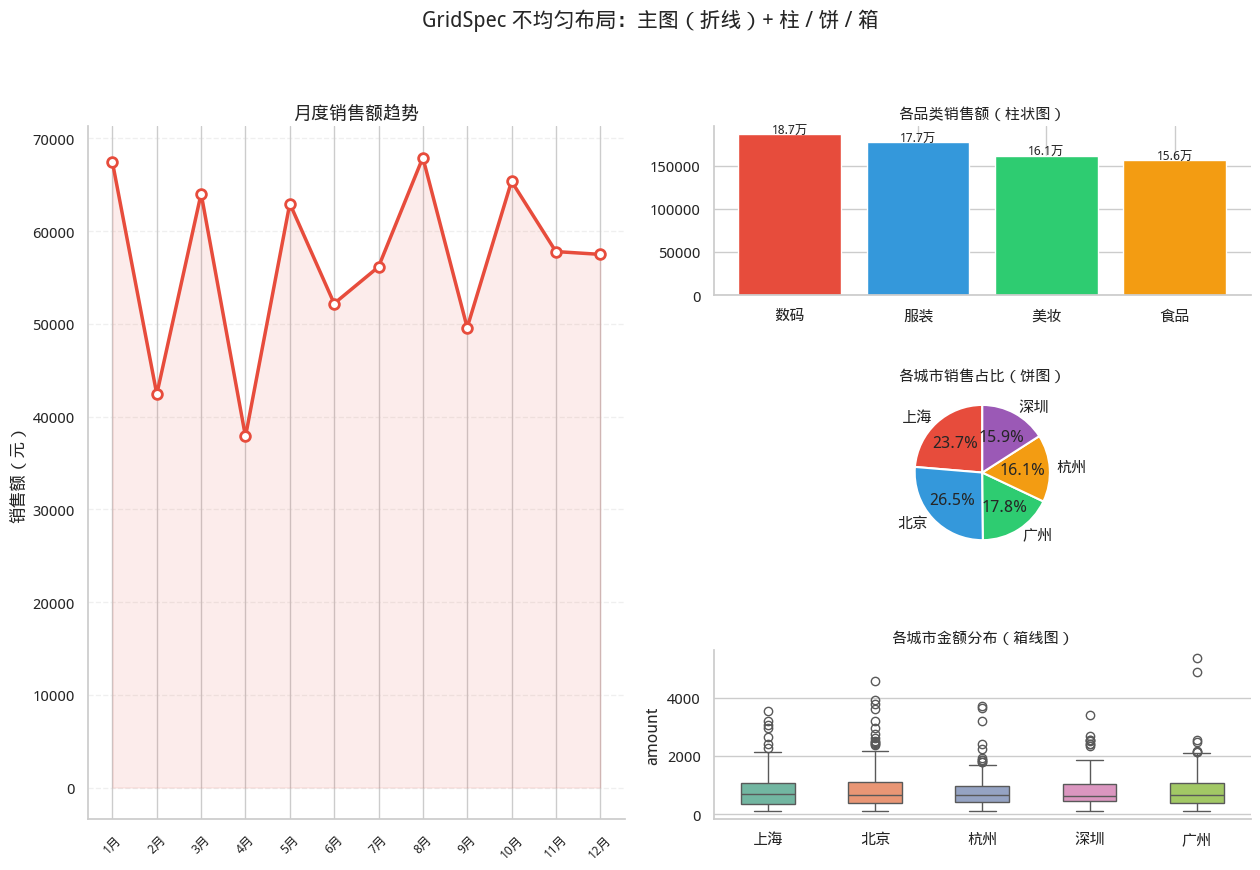

In [18]:
# 练习1：GridSpec 2×2 不均匀布局
# ── 数据预处理 ──
# 注：继续沿用综合实战里的数据
monthly = df.groupby('month')['amount'].sum().reindex(months)
cat_sales = df.groupby('category')['amount'].sum().sort_values(ascending=False)
city_sales = df.groupby('city')['amount'].sum()

fig = plt.figure(figsize=(15, 9))
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.4)

ax_main = fig.add_subplot(gs[:, :2])
ax_main.plot(monthly.index, monthly.values, marker='o', linewidth=2.5,
             color='#E74C3C', markersize=7, markerfacecolor='white', markeredgewidth=2)
ax_main.fill_between(range(len(monthly)), monthly.values, alpha=0.1, color='#E74C3C')
ax_main.set_xticks(range(len(monthly)))
ax_main.set_xticklabels(monthly.index, fontsize=9, rotation=45)
ax_main.set_title('月度销售额趋势', fontsize=13, fontweight='bold')
ax_main.set_ylabel('销售额（元）')
ax_main.spines['top'].set_visible(False)
ax_main.spines['right'].set_visible(False)
ax_main.grid(axis='y', alpha=0.3, linestyle='--')

# 柱状图
ax_bar = fig.add_subplot(gs[0, 2:])
ax_bar.bar(cat_sales.index, cat_sales.values, color=['#E74C3C','#3498DB','#2ECC71','#F39C12'], edgecolor='white')
for i, v in enumerate(cat_sales.values):
    ax_bar.text(i, v + 2000, f'{v/10000:.1f}万', ha='center', fontsize=9)
ax_bar.set_title('各品类销售额（柱状图）', fontsize=11, fontweight='bold')
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

# 饼图
ax_pie = fig.add_subplot(gs[1, 2:])
ax_pie.pie(city_sales.values, labels=city_sales.index, autopct='%1.1f%%',
           colors=colors_pie, wedgeprops=dict(edgecolor='white', linewidth=1.5), startangle=90)
ax_pie.set_title('各城市销售占比（饼图）', fontsize=11, fontweight='bold')

# 箱线图
ax_box = fig.add_subplot(gs[2, 2:])
sns.boxplot(data=df, x='city', y='amount', hue='city', palette='Set2', legend=False, width=0.5, ax=ax_box)
ax_box.set_title('各城市金额分布（箱线图）', fontsize=11, fontweight='bold')
ax_box.set_xlabel('')
ax_box.spines['top'].set_visible(False)
ax_box.spines['right'].set_visible(False)

fig.suptitle('GridSpec 不均匀布局：主图（折线）+ 柱 / 饼 / 箱', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('exercise25_1_gridspec.png', dpi=150, bbox_inches='tight')
plt.show()

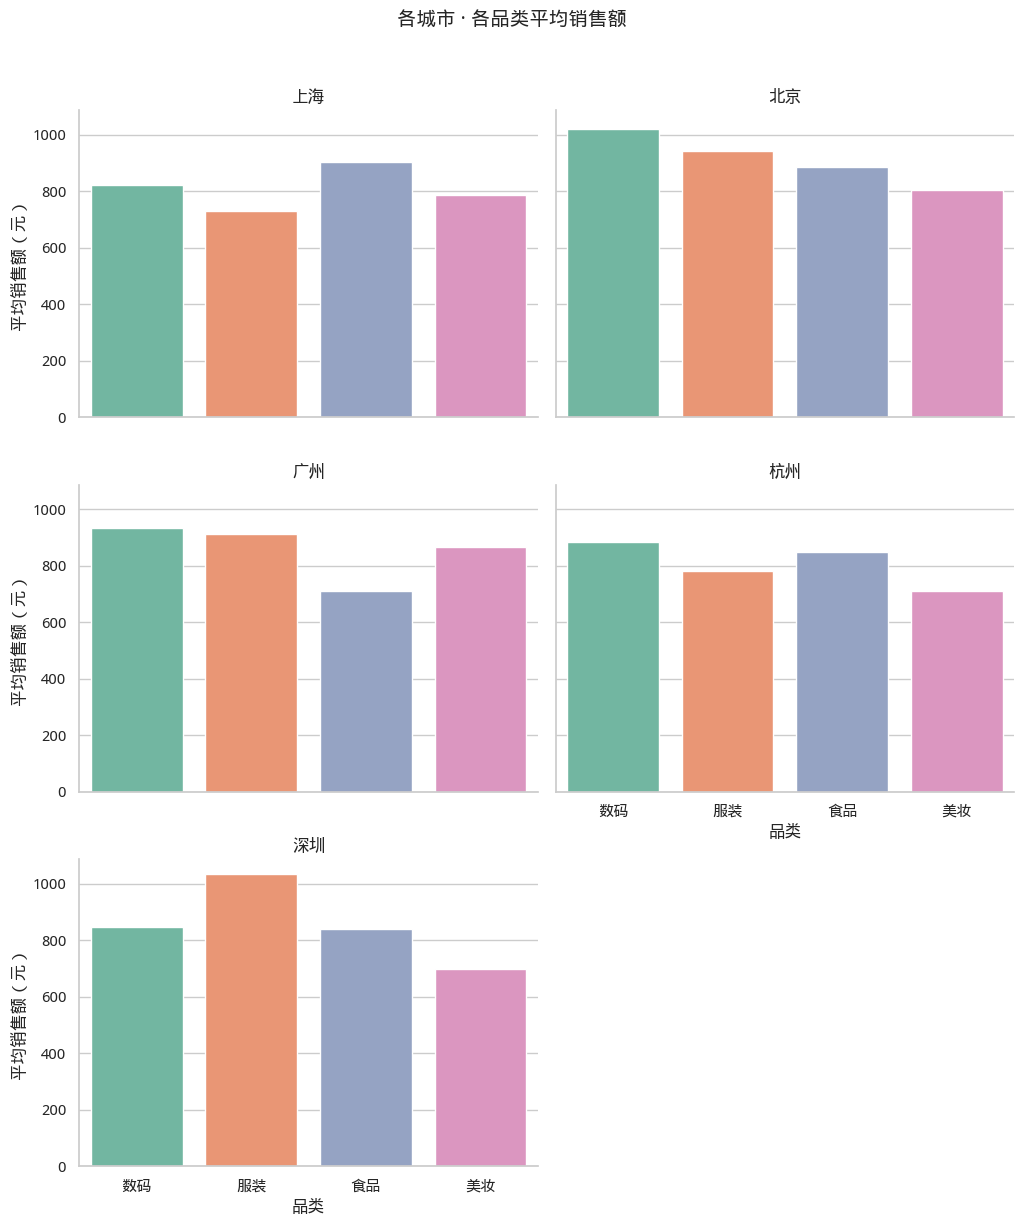

In [21]:
# 练习2：用 FacetGrid 按城市分列，分别画各品类的平均销售额柱状图。
# 各城市各品类的平均销售额
cat_avg = df.groupby(['city', 'category'])['amount'].mean().reset_index()

# FacetGrid 按城市分列
g = sns.FacetGrid(cat_avg, col='city', col_wrap=2, height=4, aspect=1.3,
                  sharey=True)
g.map_dataframe(sns.barplot, x='category', y='amount', hue='category',
                palette='Set2', legend=False, order=['数码','服装','食品','美妆'],
                hue_order=['数码','服装','食品','美妆'])

g.set_titles('{col_name}', fontweight='bold', fontsize=12)
g.set_axis_labels('品类', '平均销售额（元）')
g.figure.suptitle('各城市 · 各品类平均销售额', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('exercise25_2_facetgrid.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# 练习3：把你的第18篇实战数据做成一个完整仪表盘（至少4张子图），保存为 PNG。
%run 第18篇-阶段大实战电商用户行为分析.ipynb


原始数据形状：
  订单表: (2030, 6)
  用户表: (300, 5)
  商品表: (50, 4)

【Step 2】数据检查与清洗

缺失值统计：
order_id      0
user_id       0
product_id    0
amount        0
order_date    0
status        0
dtype: int64

重复订单数：30
去重后订单数：2000
删除 amount 缺失后：2000
异常金额订单数：0

有效已完成订单数：1218

【Step 3】多表合并
合并后数据形状：(1218, 14)
合并后列名：['order_id', 'user_id', 'product_id', 'amount', 'order_date', 'status', 'order_month', 'order_week', 'name', 'city', 'register_date', 'level', 'category', 'price_tier']

合并后 city 缺失：0
合并后 category 缺失：0

【Step 4】业务分析

📊 总体业务概况
  总 GMV：      ¥2,160,732
  总订单数：     1,218
  平均客单价：   ¥1774.0
  活跃用户数：   295

🏙️ 各城市销售情况：
        总销售额  订单数   平均客单价  用户数
city                          
上海    413342  233  1774.0   61
深圳    383184  216  1774.0   43
北京    365444  206  1774.0   52
广州    312224  176  1774.0   43
成都    251908  142  1774.0   34
杭州    241264  136  1774.0   37
武汉    193366  109  1774.0   25

🛒 各品类销售情况：
            总销售额  订单占比
category              
运动        594290  27.5
数码        431082  20.0
家居    

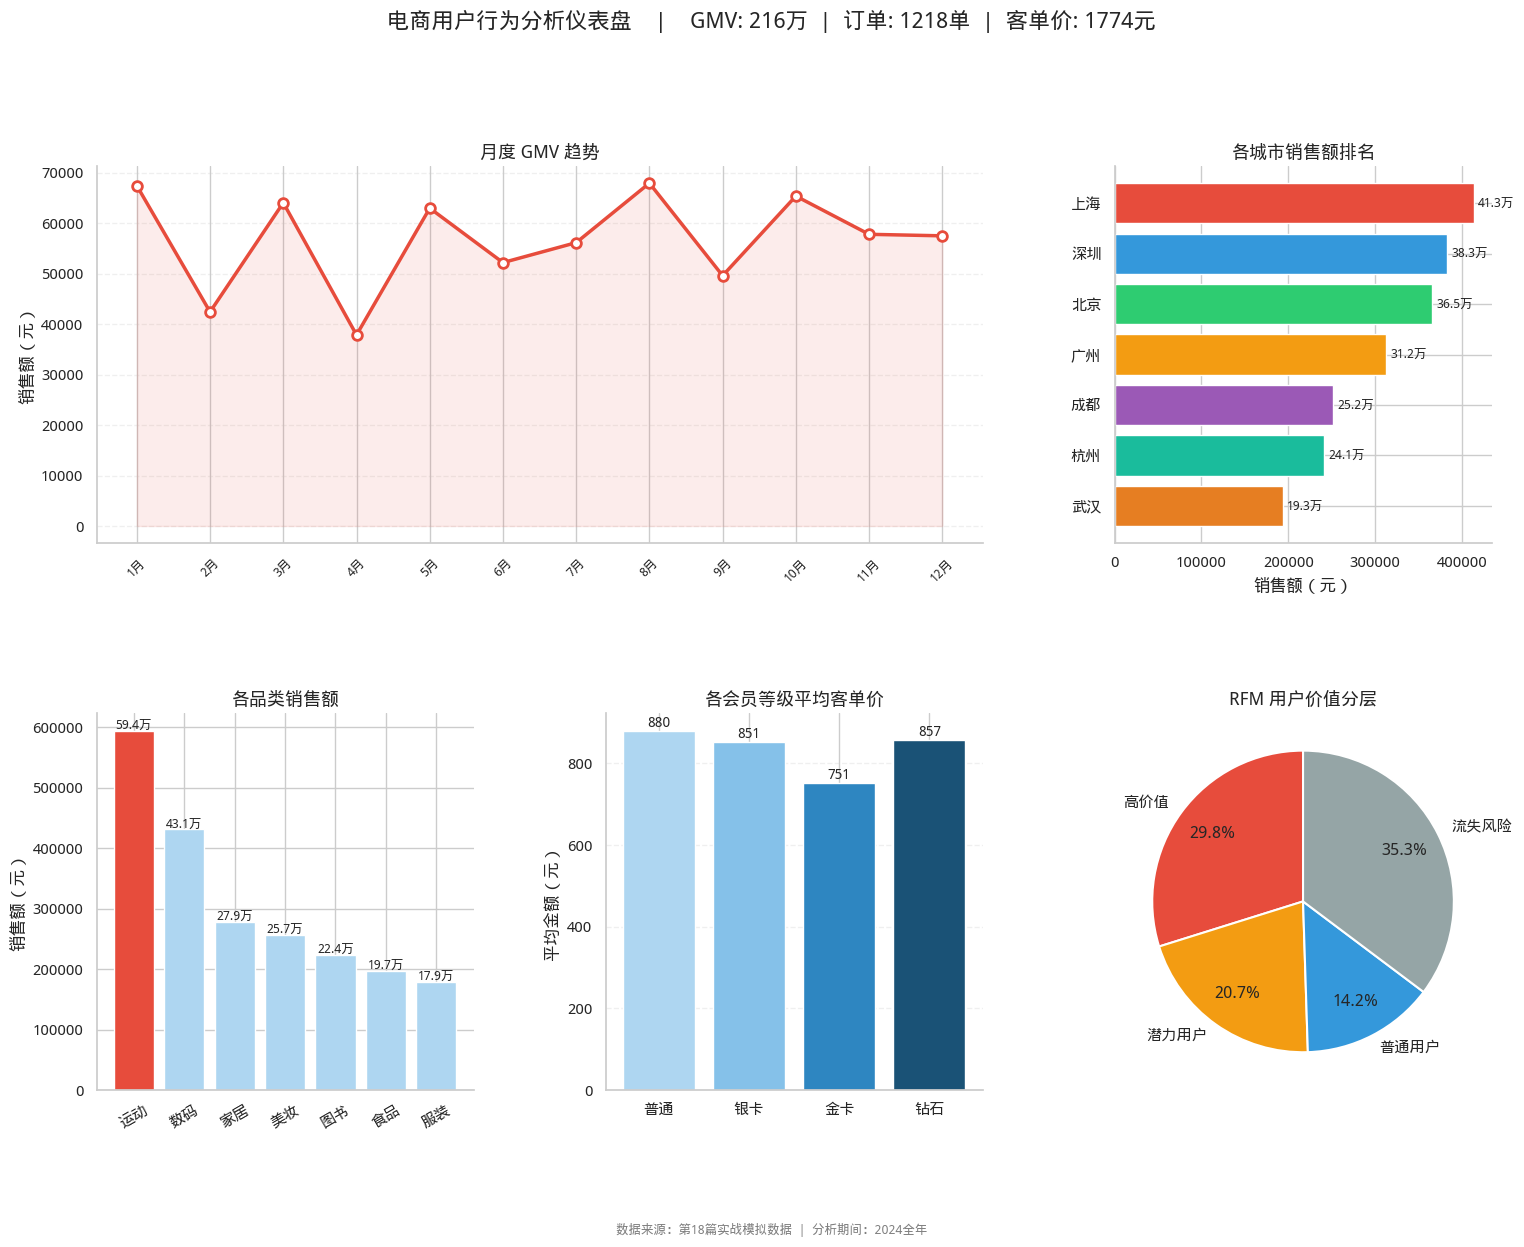

仪表盘已保存为 exercise25_3_dashboard.png


In [41]:
# ═══════════════════════════════════════════
# 仪表盘绘制（6张子图）
# ═══════════════════════════════════════════
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)


# ── 图1（跨2列）：月度 GMV 折线 ──
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(range(len(monthly_gmv)), monthly_gmv.values, marker='o', linewidth=2.5,
         color='#E74C3C', markersize=7, markerfacecolor='white', markeredgewidth=2)
ax1.fill_between(range(len(monthly_gmv)), monthly_gmv.values, alpha=0.1, color='#E74C3C')
ax1.set_xticks(range(len(monthly_gmv)))
ax1.set_xticklabels(monthly_gmv.index, fontsize=9, rotation=45)
ax1.set_title('月度 GMV 趋势', fontsize=13, fontweight='bold')
ax1.set_ylabel('销售额（元）')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')


# ── 图2：城市销售额 TOP7 横向柱状图 ──
ax2 = fig.add_subplot(gs[0, 2])
city_total = city_sales['总销售额']   # 取出一维 Series
colors_city = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6','#1ABC9C','#E67E22']
ax2.barh(city_total.index[::-1], city_total.values[::-1],
         color=colors_city[::-1], edgecolor='white')
for i, v in enumerate(city_total.values[::-1]):
    ax2.text(v + 5000, i, f'{v/10000:.1f}万', va='center', fontsize=9)
ax2.set_title('各城市销售额排名', fontsize=13, fontweight='bold')
ax2.set_xlabel('销售额（元）')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── 图3：品类销售额柱状图 ──
ax3 = fig.add_subplot(gs[1, 0])
cat_total = cat_sales['总销售额']   # 取出一维 Series
cat_colors = ['#E74C3C' if i == 0 else '#AED6F1' for i in range(len(cat_sales))]
ax3.bar(cat_total.index, cat_total.values, color=cat_colors, edgecolor='white')
for i, v in enumerate(cat_total.values):
    ax3.text(i, v + 3000, f'{v/10000:.1f}万', ha='center', fontsize=9)
ax3.set_title('各品类销售额', fontsize=13, fontweight='bold')
ax3.set_ylabel('销售额（元）')
ax3.tick_params(axis='x', rotation=30)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ── 图4：会员等级平均客单价 ──
ax4 = fig.add_subplot(gs[1, 1])
level_colors = ['#AED6F1','#85C1E9','#2E86C1','#1A5276']
ax4.bar(level_order, level_vals, color=level_colors, edgecolor='white')
for i, v in enumerate(level_vals):
    ax4.text(i, v + 10, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')
ax4.set_title('各会员等级平均客单价', fontsize=13, fontweight='bold')
ax4.set_ylabel('平均金额（元）')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.grid(axis='y', alpha=0.3, linestyle='--')

# ── 图5：RFM 用户分层饼图 ──
ax5 = fig.add_subplot(gs[1, 2])

# 源数据有emoji，先去掉，否则展示的时候会报错
type_map = {
    '⭐ 高价值用户': '高价值',
    '🔵 潜力用户':   '潜力用户',
    '🟡 新用户':     '普通用户',
    '🔴 流失风险':   '流失风险'
}
rfm['user_type'] = rfm['user_type'].map(type_map).fillna(rfm['user_type'])
type_order = ['高价值', '潜力用户', '普通用户', '流失风险']
type_counts = rfm['user_type'].value_counts()
type_vals = [type_counts.get(t, 0) for t in type_order]

type_colors = ['#E74C3C', '#F39C12', '#3498DB', '#95A5A6']
ax5.pie(type_vals, labels=type_order, autopct='%1.1f%%', colors=type_colors,
        wedgeprops=dict(edgecolor='white', linewidth=1.5), startangle=90, pctdistance=0.75)
ax5.set_title('RFM 用户价值分层', fontsize=13, fontweight='bold')

# ── 大标题 & 页脚 ──
total_gmv = df['amount'].sum()
total_orders = len(df)
avg_order = df['amount'].mean()
fig.suptitle(f'电商用户行为分析仪表盘    |    GMV: {total_gmv/10000:.0f}万  |  订单: {total_orders}单  |  客单价: {avg_order:.0f}元',
             fontsize=16, fontweight='bold', y=1.01)
fig.text(0.5, -0.01, '数据来源：第18篇实战模拟数据  |  分析期间：2024全年',
         ha='center', fontsize=9, color='gray')

plt.savefig('exercise25_3_dashboard.png', dpi=150, bbox_inches='tight')
plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.show()
print("仪表盘已保存为 exercise25_3_dashboard.png")

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 26 篇：交互式可视化 — Plotly 入门**
>
> 下篇来学 Plotly 交互式可视化——可缩放、可悬停、可点击的动态图表，在 Jupyter 和 Web 上展示效果绝佳。

---

*跟着小荷，数据分析路上不迷路～*